# alterei teste==============================================================================
# LABORATÓRIO PRÁTICO: MACHINE LEARNING & VERSIONAMENTO
# Objetivo: Prever se um vinho é "Bom" ou "Ruim" baseado na sua química.
# ==============================================================================

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

In [3]:
print("Baixando base de dados da internet...")
# 1. Carregando os dados reais (Dataset de Vinhos Tintos da UCI)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

Baixando base de dados da internet...


In [4]:
# 2. Preparando os dados (Regra de Negócio: Qualidade >= 6 é Vinho Bom)
df['classificacao'] = [1 if nota >= 6 else 0 for nota in df['quality']]

In [5]:
# Separando o que é Característica (X) do que é a Resposta (y)
X = df.drop(['quality', 'classificacao'], axis=1)
y = df['classificacao']

In [6]:
# 3. Separando os dados para Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print("Treinando a Inteligência Artificial...")

# ==============================================================================
#  DESAFIO DO PULL REQUEST PARA OS ALUNOS:
# TODO: Altere o número de "n_estimators" (árvores de decisão). 
# Tente valores como 10, 50, 200 ou 500 e veja se a precisão melhora ou piora!
# Após alterar, faça o Commit e abra um Pull Request detalhando sua mudança.
# ==============================================================================

numero_de_arvores = 100  # <-


Treinando a Inteligência Artificial...


In [8]:
modelo = RandomForestClassifier(n_estimators=numero_de_arvores, random_state=42)

# 4. Treinando o modelo com os dados
modelo.fit(X_train, y_train)

# 5. Fazendo a IA tentar adivinhar os vinhos de teste
previsoes = modelo.predict(X_test)

In [9]:
# 6. Verificando a nota e as métricas
precisao = accuracy_score(y_test, previsoes)
print("\n" + "=" * 50)
print(f"Precisão Global do Modelo (Accuracy): {precisao * 100:.2f}%")
print("=" * 50)


Precisão Global do Modelo (Accuracy): 79.06%


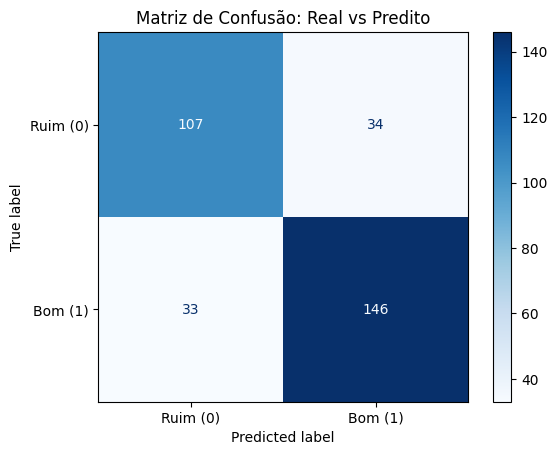

In [10]:
# Configurando o visual do gráfico
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    previsoes, 
    display_labels=['Ruim (0)', 'Bom (1)'],
    cmap=plt.cm.Blues # Cor azulada para ficar profissional
)

# Adicionando um título
plt.title("Matriz de Confusão: Real vs Predito")

# Exibindo a janela do gráfico na tela do aluno
plt.show()

In [11]:
print("\nRELATÓRIO DE CLASSIFICAÇÃO:")
print("-" * 50)
print(classification_report(y_test, previsoes))


RELATÓRIO DE CLASSIFICAÇÃO:
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       141
           1       0.81      0.82      0.81       179

    accuracy                           0.79       320
   macro avg       0.79      0.79      0.79       320
weighted avg       0.79      0.79      0.79       320

